# 01 数据集分析

本笔记本用于数据健全性检查，在大规模模型训练之前验证以下内容：

1. **配置审查**：扫描 `run/conf/` 下的 YAML 配置，检查关键参数
2. **数据集构建**：使用 `TrajectoryDataHandler` 生成轻量级分析数据集
3. **可视化诊断**：DOA 轨迹、分布、阵列快照热力图
4. **统计检查**：角度统计、信号源分布、边界饱和检测
5. **分割验证**：训练/验证/测试集无泄漏验证

In [1]:
# STEP 01: Initialize the notebook runtime context and shared analysis defaults.
# step 1.1: This cell only prepares imports, paths, seeds, and plotting style.
from pathlib import Path
import sys
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import yaml

# step 1.2: Resolve the project root; move up one level when executed from notebooks/.
ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

# step 1.3: Add the project root so config/ and src/ are importable from this notebook.
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# step 1.4: Add the DCD_MUSIC submodule path for downstream data generation utilities.
DCD_ROOT = ROOT / "DCD_MUSIC"
if str(DCD_ROOT) not in sys.path:
    sys.path.append(str(DCD_ROOT))

# step 1.5: Standardize the figure output directory; nb1/ isolates this notebook's outputs.
FIG_DIR = ROOT / "figures" / "nb1"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# STEP 02: Fix plotting defaults and random seeds for reproducible inspection.
# Okabe-Ito colorblind-friendly palette
OKABE_ITO = ["#0072B2", "#E69F00", "#009E73", "#D55E00", "#56B4E9", "#CC79A7", "#F0E442", "#000000"]

plt.rcParams.update({
    "figure.dpi": 150,           # Preview only; save with savefig(dpi=600)
    "figure.figsize": (7, 4),    # Double-column default
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",
    "font.size": 10,
    "lines.linewidth": 1.5,
    "lines.markersize": 5,
    "axes.prop_cycle": plt.cycler(color=OKABE_ITO),
    "savefig.format": "pdf",     # Vector format by default
    "savefig.bbox": "tight",
    "savefig.dpi": 600,          # High-res for raster fallback
})

np.random.seed(42)
torch.manual_seed(42)

print(f"Project root : {ROOT}")
print(f"DCD_MUSIC    : {DCD_ROOT}")
print(f"Figure output: {FIG_DIR}")

Project root : /Users/lilei/myRepo/SubspaceNet_Update
DCD_MUSIC    : /Users/lilei/myRepo/SubspaceNet_Update/DCD_MUSIC
Figure output: /Users/lilei/myRepo/SubspaceNet_Update/figures/nb1


### 环境初始化说明

上面的单元格完成了三件事：
1. **路径解析**：定位项目根目录，将 `ROOT` 和 `DCD_MUSIC` 加入 `sys.path`（本地 `src` 优先）
2. **可重复性**：固定 numpy/torch 随机种子（42）
3. **输出目录**：创建 `figures/` 目录用于保存图表

## 1) 配置审查

扫描 `run/conf/` 下所有 YAML 配置文件，将嵌套结构扁平化为 `(file, key, value)` 三元组，
重点检查系统模型、数据集、轨迹、训练等关键参数。

In [2]:
def _flatten(prefix: str, obj) -> list:
    """Recursively flatten a nested mapping into dotted-key pairs.

    Args:
        prefix: Current dotted prefix accumulated by recursion.
        obj: Current value, either a nested dict or a leaf value.

    Yields:
        tuple[str, object]: Flattened dotted key and its leaf value.
    """
    if isinstance(obj, dict):
        for k, v in obj.items():
            next_prefix = f"{prefix}.{k}" if prefix else str(k)
            yield from _flatten(next_prefix, v)
    else:
        yield prefix, obj

# STEP 03: Scan run/conf and convert all YAML files into a flat inspection table.
conf_dir = ROOT / "run" / "conf"
yaml_files = sorted(conf_dir.rglob("*.yaml"))
if not yaml_files:
    raise FileNotFoundError(f"No YAML files found under {conf_dir}")

rows = []
for yfile in yaml_files:
    with yfile.open("r", encoding="utf-8") as f:
        cfg = yaml.safe_load(f) or {}
    for k, v in _flatten("", cfg):
        rows.append({
            "file": str(yfile.relative_to(ROOT)),
            "key": k,
            "value": v,
        })

cfg_df = pd.DataFrame(rows)
print(f"扫描到 {len(yaml_files)} 个 YAML 文件，共 {len(cfg_df)} 个扁平化键值对\n")

# step 3.1: Group by the first few path segments to see where configs are concentrated.
file_groups = cfg_df["file"].apply(lambda x: "/".join(x.split("\\")[:3])).value_counts()
print("配置文件分布：")
print(file_groups.to_string())

# step 3.2: Narrow the review to the config families that drive this analysis notebook.
focus_prefixes = (
    "system_model.", "dataset.", "trajectory.",
    "training.", "evaluation.", "kalman_filter.",
)
focus_df = cfg_df[cfg_df["key"].str.startswith(focus_prefixes)].copy()
focus_df.sort_values(["file", "key"], inplace=True)

print(f"\n关键参数（匹配 {len(focus_df)} 条）：")
focus_df.head(60)

扫描到 33 个 YAML 文件，共 1571 个扁平化键值对

配置文件分布：
file
run/conf/Used_for_paper/SineAccel_base_model_Online_learning_snr_sweep_config.yaml    94
run/conf/Used_for_paper/online_learning_config.yaml                                   89
run/conf/online_learning_config.yaml                                                  89
run/conf/online_learning_unsupervised_rmape_config.yaml                               89
run/conf/online_learning_unsupervised_rmspe_config.yaml                               89
run/conf/online_learning_y_s_inv_y_config.yaml                                        89
run/conf/Legacy/nonlinear_tracking_config.yaml                                        79
run/conf/train_model_config.yaml                                                      77
run/conf/default_config.yaml                                                          72
run/conf/training_config/nonlinear_tracking_training_config.yaml                      72
run/conf/evaluation_configs/calibration_sweep_error_config.yaml 

,file,key,value
17,run/conf/Legacy/eta_scenario.yaml,dataset.create_data,True
15,run/conf/Legacy/eta_scenario.yaml,dataset.samples_size,1024
18,run/conf/Legacy/eta_scenario.yaml,dataset.save_dataset,False
16,run/conf/Legacy/eta_scenario.yaml,dataset.test_validation_train_split,"[0.2, 0.2, 0.6]"
21,run/conf/Legacy/eta_scenario.yaml,dataset.true_doa_test,None
19,run/conf/Legacy/eta_scenario.yaml,dataset.true_doa_train,None
22,run/conf/Legacy/eta_scenario.yaml,dataset.true_range_test,None
20,run/conf/Legacy/eta_scenario.yaml,dataset.true_range_train,None
60,run/conf/Legacy/eta_scenario.yaml,kalman_filter.initial_covariance,1.0
59,run/conf/Legacy/eta_scenario.yaml,kalman_filter.measurement_noise_std_dev,0.001


### 配置检查要点

- `system_model.N / M / T`：天线数、信号源数、快拍数是否匹配实验设计？
- `dataset.samples_size`：样本量是否足够？
- `trajectory.trajectory_type`：轨迹运动模型是否正确？
- `training.batch_size` vs `dataset.samples_size`：比例是否合理？
- `kalman_filter.measurement_noise`：量测噪声参数量级是否合适？

## 2) 构建轻量级分析数据集

通过 `config/loader.py` 加载默认配置，覆盖样本量和轨迹长度以加速分析。
使用 `TrajectoryDataHandler.create_dataset()` 生成数据集和 `Samples` 模型实例。

Running on device:  cpu
=== 系统模型配置 ===
  天线数 N      = 8
  信号源数 M    = 3
  快拍数 T      = 200
  信噪比 SNR    = 10.0 dB
  DOA 范围      = [-60, 60]°
  场类型        = far
  校准误差 eta  = 0.0

=== 数据集配置 ===
  样本量        = 128
  轨迹长度      = 30
  轨迹类型      = TrajectoryType.RANDOM_WALK
  分割比例      = [0.2, 0.2, 0.6]

=== 数据集概况 ===
  轨迹数量      = 128
  轨迹长度 L    = 30
  单样本 X 形状 = (30, 8, 200)  [L, N, T]
  标签示例      = [-0.131, 0.472, 0.243] (rad)


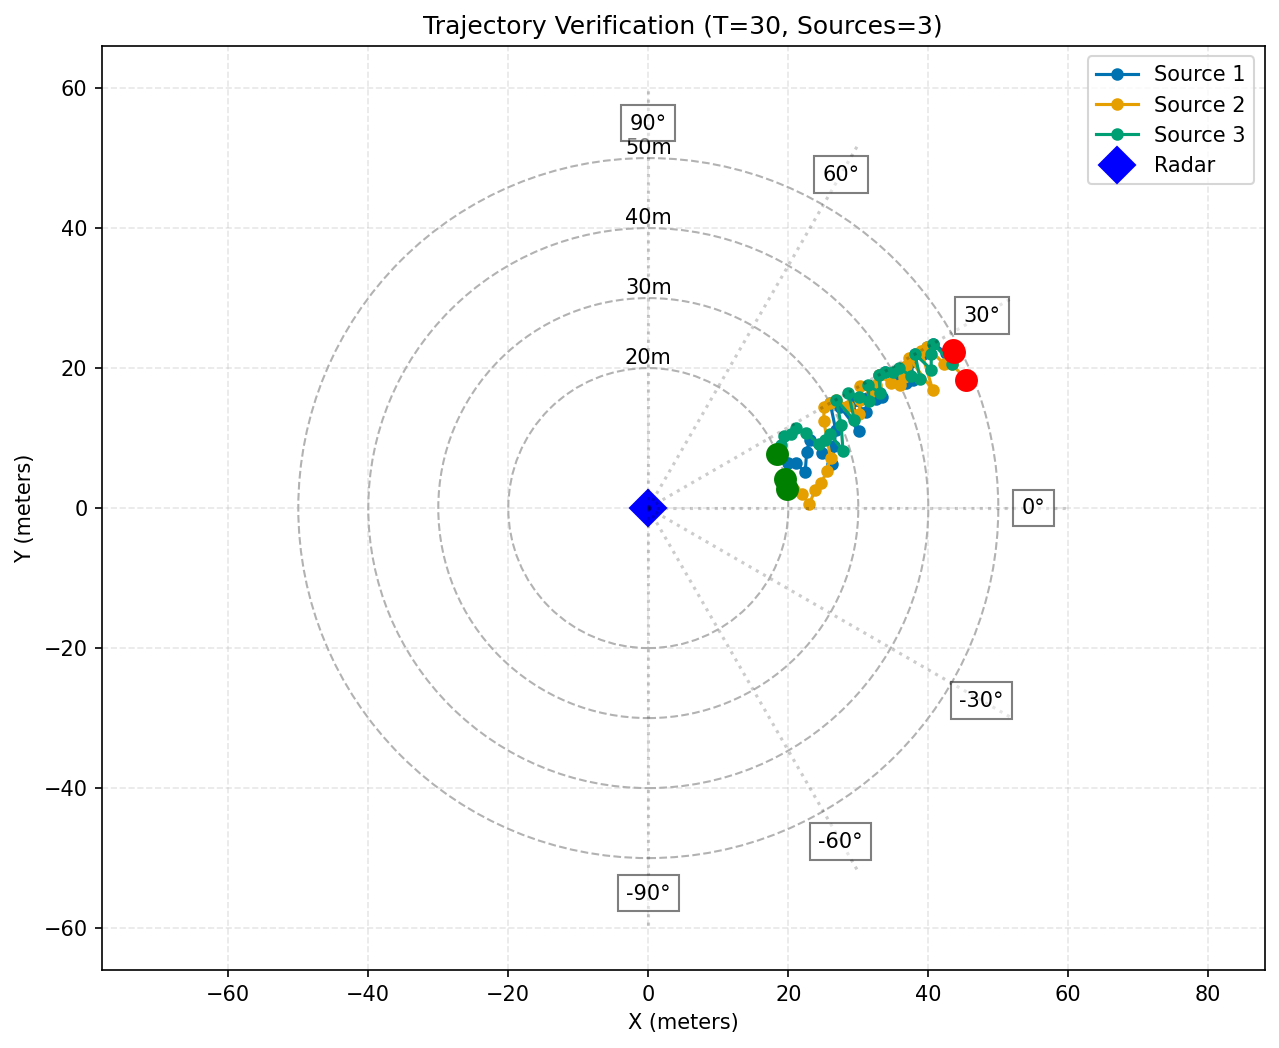

In [3]:
# STEP 04: Build a lightweight dataset for quick, interactive inspection.
from src.data_module.trajectory import TrajectoryDataHandler
from config.loader import load_config
from config.utils import create_system_model

# step 4.1: Fail early if the submodule is missing instead of surfacing a later import/runtime error.
if not DCD_ROOT.exists() or not any(DCD_ROOT.iterdir()):
    raise RuntimeError(
        "DCD_MUSIC 子模块为空，请运行: git submodule update --init --recursive"
    )

# step 4.2: Start from the default project config to preserve the main code path.
config_path = ROOT / "run" / "conf" / "default_config.yaml"
config = load_config(str(config_path))

# step 4.3: Override only size-related knobs to make notebook analysis fast.
config.dataset.samples_size = 128
config.trajectory.trajectory_length = 30
config.trajectory.enabled = True

# step 4.4: Print the active hyperparameters so later plots can be interpreted in context.
print("=== 系统模型配置 ===")
print(f"  天线数 N      = {config.system_model.N}")
print(f"  信号源数 M    = {config.system_model.M}")
print(f"  快拍数 T      = {config.system_model.T}")
print(f"  信噪比 SNR    = {config.system_model.snr} dB")
print(f"  DOA 范围      = [-{config.system_model.doa_range}, {config.system_model.doa_range}]°")
print(f"  场类型        = {config.system_model.field_type}")
print(f"  校准误差 eta  = {config.system_model.eta}")

print(f"\n=== 数据集配置 ===")
print(f"  样本量        = {config.dataset.samples_size}")
print(f"  轨迹长度      = {config.trajectory.trajectory_length}")
print(f"  轨迹类型      = {config.trajectory.trajectory_type}")
print(f"  分割比例      = {config.dataset.test_validation_train_split}")

# step 4.5: Reuse the real data pipeline, but keep save_dataset disabled for analysis-only runs.
system_model = create_system_model(config)
handler = TrajectoryDataHandler(system_model_params=system_model.params, config=config)

dataset, samples_model = handler.create_dataset(
    samples_size=config.dataset.samples_size,
    trajectory_length=config.trajectory.trajectory_length,
    trajectory_type=config.trajectory.trajectory_type,
    save_dataset=False,
)

print(f"\n=== 数据集概况 ===")
print(f"  轨迹数量      = {len(dataset)}")
print(f"  轨迹长度 L    = {dataset.trajectory_length}")
print(f"  单样本 X 形状 = {tuple(dataset.time_series[0].shape)}  [L, N, T]")
print(f"  标签示例      = {[float(f'{v:.3f}') for v in dataset.labels[0][0][:config.system_model.M]]} (rad)")

### 数据集结构说明

- `dataset.time_series[i]`：第 i 条轨迹的阵列观测，形状 `[L, N, T]`
  - `L` = 轨迹长度（时间步数）
  - `N` = 天线数
  - `T` = 每步快拍数
- `dataset.labels[i][t]`：第 i 条轨迹第 t 步的真实 DOA 角度（弧度）M个
- `dataset.sources_num[i][t]`：第 i 条轨迹第 t 步的信号源数量

## 3) 可视化诊断

本节包含四种视觉检查：
1. **单条轨迹 DOA 演化**：展示每个信号源随时间的角度变化
2. **DOA 均值 + 95% 置信带**：检测漂移和边界饱和
3. **小提琴图**：DOA、经验 SNR、噪声强度的分布形态
4. **阵列快照热力图**：检查空间-时间结构

### 3a) 单条轨迹 DOA 演化

展示前 4 条轨迹中每个信号源的角度随时间步的变化，直观检查运动模型行为。

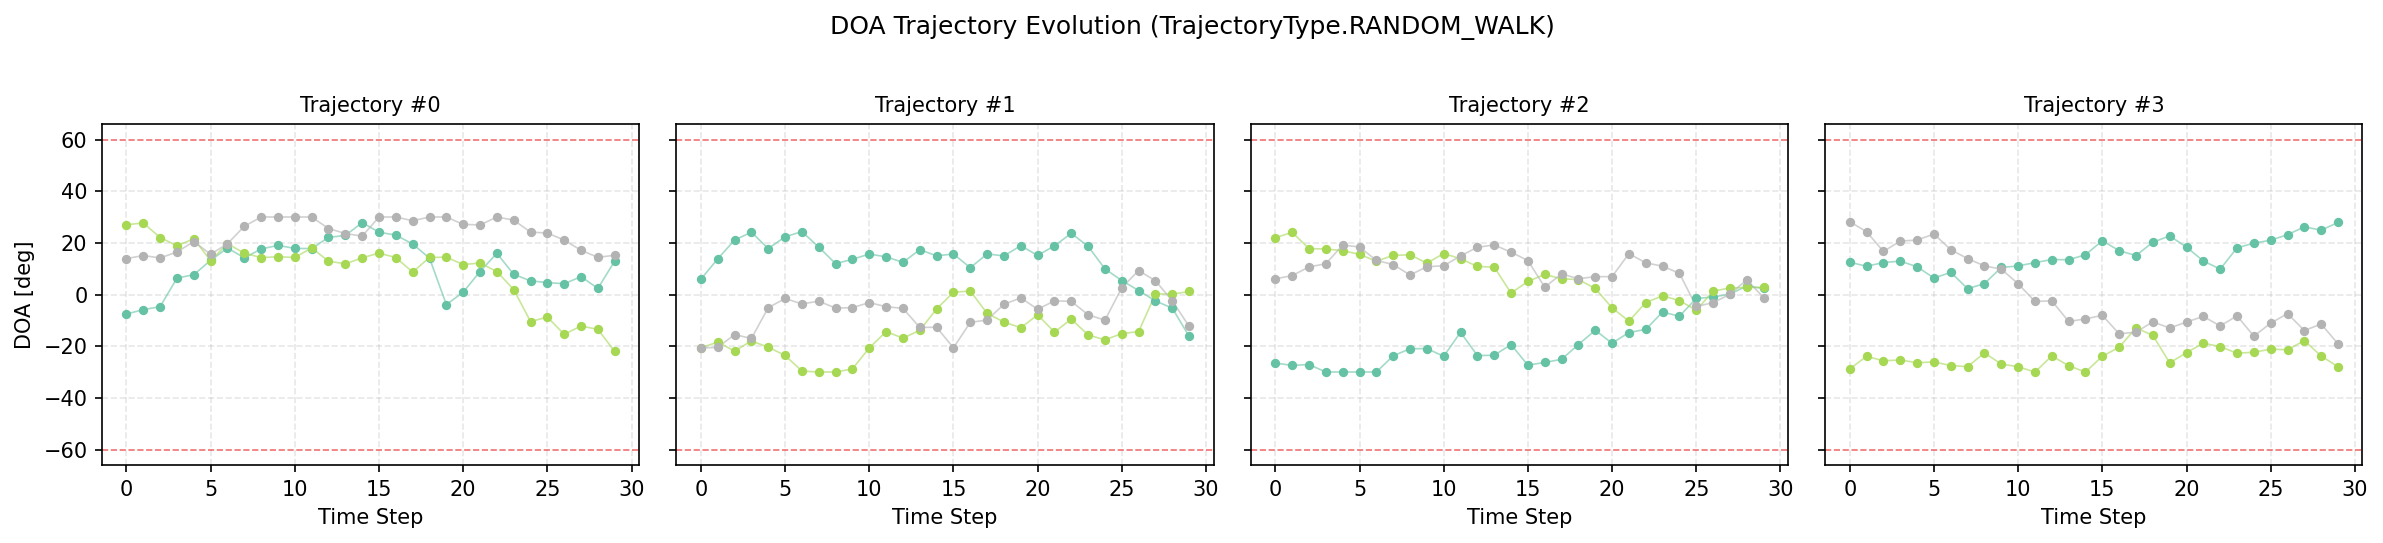

In [4]:
# STEP 05: Plot source-angle trajectories to sanity check the motion model visually.
# 3a) Single trajectory DOA evolution (first 4)
trajectory_length = dataset.trajectory_length
n_show = min(4, len(dataset))
colors = plt.cm.Set2(np.linspace(0, 1, config.system_model.M))

fig, axes = plt.subplots(1, n_show, figsize=(4 * n_show, 3.5), sharey=True)
if n_show == 1:
    axes = [axes]

for idx, ax in enumerate(axes):
    for t in range(trajectory_length):
        # step 5.1: Use the active source count at each time step to avoid padded entries.
        m_t = int(dataset.sources_num[idx][t])
        angles_deg = np.rad2deg(np.asarray(dataset.labels[idx][t], dtype=np.float32)[:m_t])
        for s in range(m_t):
            ax.scatter(t, angles_deg[s], color=colors[s], s=12, zorder=3)
            if t > 0:
                prev_m = int(dataset.sources_num[idx][t - 1])
                if s < prev_m:
                    prev_angle = np.rad2deg(float(dataset.labels[idx][t - 1][s]))
                    ax.plot([t - 1, t], [prev_angle, angles_deg[s]],
                            color=colors[s], linewidth=0.8, alpha=0.6)

    # step 5.2: Draw DOA limits as reference lines to reveal boundary clipping.
    ax.axhline(-config.system_model.doa_range, color="r", ls="--", lw=0.8, alpha=0.5)
    ax.axhline(config.system_model.doa_range, color="r", ls="--", lw=0.8, alpha=0.5)
    ax.set_title(f"Trajectory #{idx}", fontsize=10)
    ax.set_xlabel("Time Step")
    if idx == 0:
        ax.set_ylabel("DOA [deg]")

fig.suptitle(f"DOA Trajectory Evolution ({config.trajectory.trajectory_type})", fontsize=12, y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "dataset_doa_trajectory.png", dpi=180, bbox_inches="tight")
plt.show()

### 3b) DOA 均值 + 95% 置信带

聚合所有样本/信号源的 DOA，计算每个时间步的均值和 95% 置信区间。
用于检测系统性漂移和边界饱和。

### 3b) 图表解读：DOA 均值与标准差

**上图：DOA Trajectory Mean with 95% Confidence Band**

- **蓝线（均值）**：每个时间步 t，汇总所有轨迹 × 所有信源（共 128×3=384 个角度值）后计算均值。由于轨迹起点在 `[-doa_range, +doa_range]` 内对称随机初始化，且随机游走增量均值为 0，因此均值始终稳定在 **0° 附近**，无系统性漂移。
- **蓝色阴影（95% CI）**：`mean ± 1.96 × SEM`，其中 `SEM = std / √384`。因样本量大（n=384），SEM 极小，置信带非常窄——这反映的是对**均值估计的精度高**，而非数据本身波动小。
- **红色虚线**：DOA 允许范围边界 `±doa_range`，用于检测角度是否超界。

**下图：DOA Standard Deviation over Time**

- 每个时间步的跨轨迹标准差，反映**所有轨迹的角度离散程度**。
- 理论上随机游走的 std 应随时间增长（`std ∝ √t`），但由于边界裁剪（`np.clip`），大量轨迹碰到 `±doa_range` 后被截断，std 不再增大，最终在约 **18°** 处饱和。
- 均匀分布 `[-a, a]` 的理论标准差为 `a/√3`，可验证：`doa_range / √3 ≈ 60/1.73 ≈ 34.6°`（若 doa_range=60）。实际饱和值低于此，说明边界裁剪后分布并非完全均匀。
- **诊断意义**：std 过早饱和 → 运动幅度过大，轨迹频繁碰壁，可减小 `random_walk_std_dev`；std 始终很小 → 轨迹几乎静止，可增大 `random_walk_std_dev`。

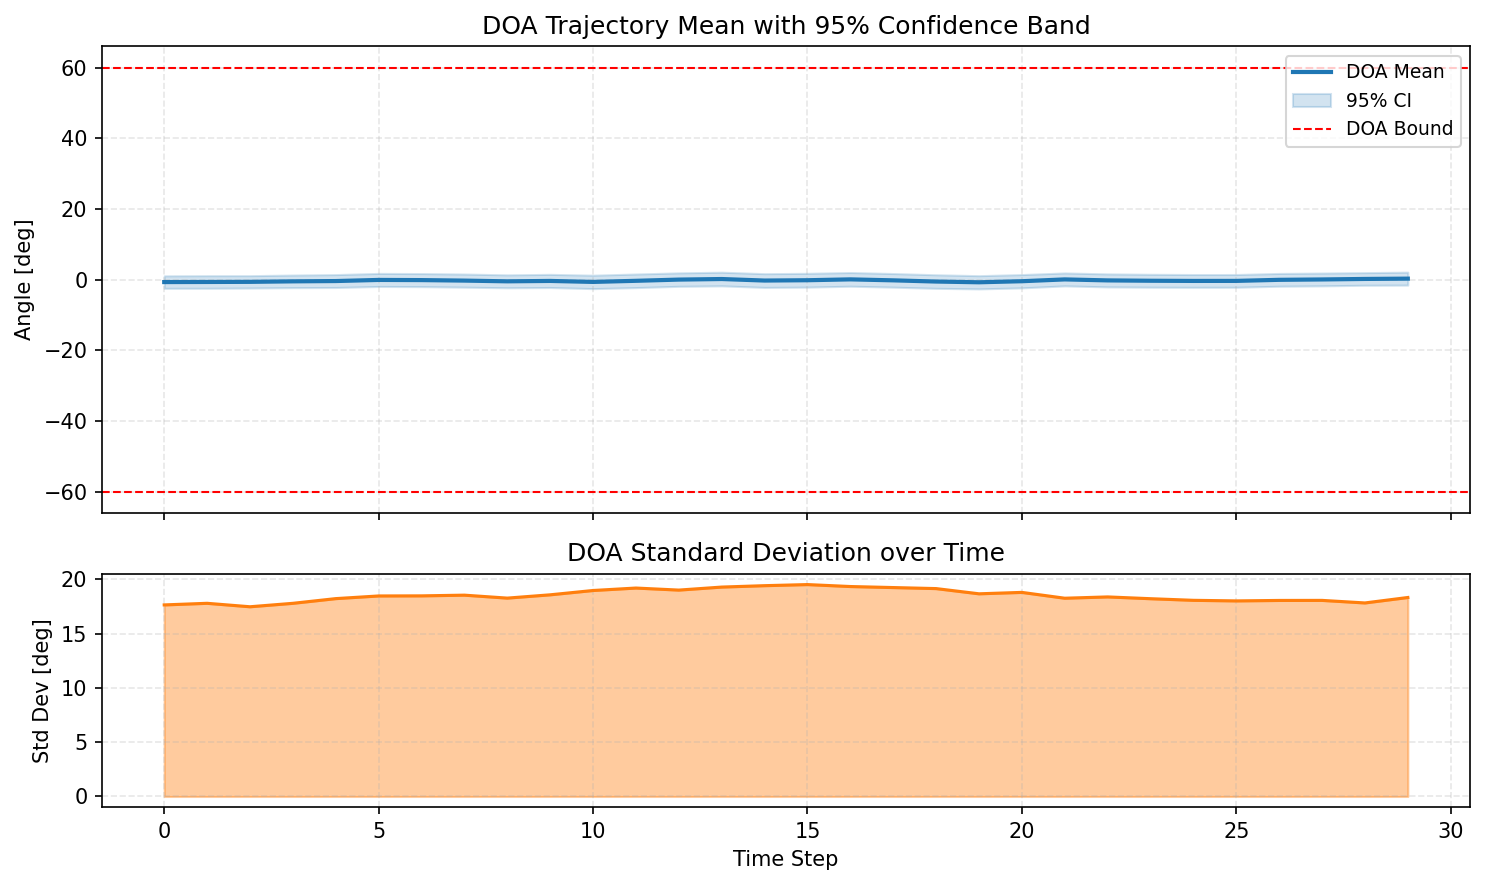

In [5]:
# STEP 06: Aggregate DOA values over time and estimate the mean plus a 95% band.
# 3b) DOA Mean + 95% Confidence Band
angle_records = [[] for _ in range(trajectory_length)]
for i in range(len(dataset.labels)):
    for t in range(trajectory_length):
        m_t = int(dataset.sources_num[i][t])
        angles_deg = np.rad2deg(np.asarray(dataset.labels[i][t], dtype=np.float32)[:m_t])
        angle_records[t].extend(angles_deg.tolist())

means, ci95_low, ci95_high, stds = [], [], [], []
for vals in angle_records:
    arr = np.asarray(vals, dtype=np.float32)
    n = max(1, arr.size)
    mean = float(np.mean(arr))
    std = float(np.std(arr, ddof=1)) if n > 1 else 0.0
    sem = std / np.sqrt(n)
    ci = 1.96 * sem  # 1.96 is the usual normal-approximation factor for a two-sided 95% interval.
    means.append(mean)
    ci95_low.append(mean - ci)
    ci95_high.append(mean + ci)
    stds.append(std)

x = np.arange(trajectory_length)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True,
                                gridspec_kw={"height_ratios": [2, 1]})

# step 6.1: The top panel shows central tendency and uncertainty over time.
ax1.plot(x, means, color="#1f77b4", linewidth=2.0, label="DOA Mean")
ax1.fill_between(x, ci95_low, ci95_high, color="#1f77b4", alpha=0.2, label="95% CI")
ax1.axhline(-config.system_model.doa_range, color="r", ls="--", lw=1, label="DOA Bound")
ax1.axhline(config.system_model.doa_range, color="r", ls="--", lw=1)
ax1.set_ylabel("Angle [deg]")
ax1.set_title("DOA Trajectory Mean with 95% Confidence Band")
ax1.legend(loc="best", fontsize=9)

# step 6.2: The bottom panel isolates spread so variance changes are easier to see.
ax2.fill_between(x, 0, stds, color="#ff7f0e", alpha=0.4)
ax2.plot(x, stds, color="#ff7f0e", linewidth=1.5)
ax2.set_xlabel("Time Step")
ax2.set_ylabel("Std Dev [deg]")
ax2.set_title("DOA Standard Deviation over Time")

fig.tight_layout()
fig.savefig(FIG_DIR / "dataset_doa_mean_ci.png", dpi=180)
plt.show()

### 3c) 小提琴图：DOA / 经验 SNR / 噪声分布

小提琴图比直方图更清晰地展示分布的偏斜和多模态特征。

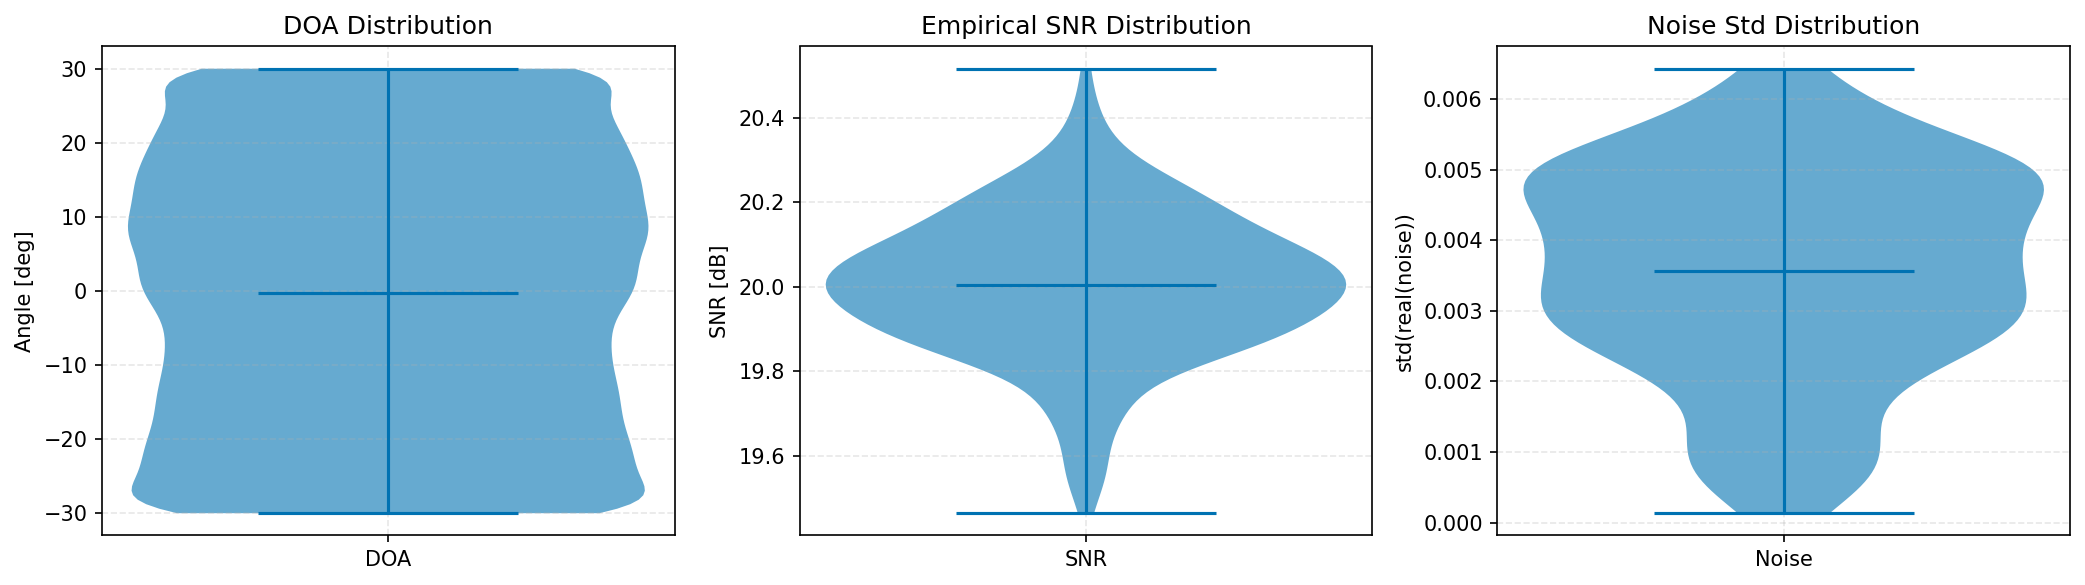

Empirical SNR: mean=20.00 dB, std=0.17 dB, n_samples=240


In [6]:
# STEP 07: Compare the empirical distributions of DOA, SNR, and noise scale.
# 3c) Violin plots
snr_samples_db = []
noise_std_samples = []

# step 7.1: Subsample trajectories and steps so the notebook remains responsive.
max_eval = min(24, len(dataset.labels))
for i in range(max_eval):
    max_steps = min(10, len(dataset.labels[i]))
    for t in range(max_steps):
        y_rad = np.asarray(dataset.labels[i][t], dtype=np.float32)
        m_t = int(dataset.sources_num[i][t])
        samples_model.set_doa(y_rad.tolist(), m_t)
        if config.system_model.field_type.lower() != "far":
            samples_model.set_range([20.0] * m_t, m_t)  # 20.0 is a fixed example near-field range for diagnostics.

        out = samples_model.samples_creation(
            noise_mean=0, noise_variance=1,
            signal_mean=0, signal_variance=1,
            source_number=m_t,
        )
        if not isinstance(out, tuple) or len(out) < 3:
            continue
        _, signal, noise = out[0], np.asarray(out[1]), np.asarray(out[2])
        sig_pwr = float(np.mean(np.abs(signal) ** 2))
        noise_pwr = float(np.mean(np.abs(noise) ** 2))
        if noise_pwr <= 0:
            continue
        snr_samples_db.append(10.0 * math.log10(sig_pwr / noise_pwr))
        noise_std_samples.append(float(np.std(np.real(noise))))

# step 7.2: Collect all DOA values so each violin summarizes the full angle population.
all_angles_deg = []
for i in range(len(dataset.labels)):
    for t in range(len(dataset.labels[i])):
        m_t = int(dataset.sources_num[i][t])
        all_angles_deg.extend(
            np.rad2deg(np.asarray(dataset.labels[i][t], dtype=np.float32)[:m_t]).tolist()
        )

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
titles = ["DOA Distribution", "Empirical SNR Distribution", "Noise Std Distribution"]
data_list = [all_angles_deg, snr_samples_db, noise_std_samples]
ylabels = ["Angle [deg]", "SNR [dB]", "std(real(noise))"]
xtick_labels = ["DOA", "SNR", "Noise"]

for ax, title, data, ylabel, xtl in zip(axes, titles, data_list, ylabels, xtick_labels):
    if data:
        parts = ax.violinplot([data], showmeans=True, showextrema=True)
        for pc in parts["bodies"]:
            pc.set_alpha(0.6)
    ax.set_xticks([1])
    ax.set_xticklabels([xtl])
    ax.set_ylabel(ylabel)
    ax.set_title(title)

fig.tight_layout()
fig.savefig(FIG_DIR / "dataset_distribution_violins.png", dpi=180)
plt.show()

if snr_samples_db:
    print(f"Empirical SNR: mean={np.mean(snr_samples_db):.2f} dB, "
          f"std={np.std(snr_samples_db):.2f} dB, "
          f"n_samples={len(snr_samples_db)}")

DOA Distribution — 基本正常，有轻微边界堆积

形状大致均匀，均值在 0° 附近 ✓
两端（±30°）略宽 → 少量轨迹被边界裁剪，但不严重
结论：可以接受，若想更干净可适当减小 random_walk_std_dev
Empirical SNR — 异常，实际 SNR ≈ 20dB，高于配置值 10dB

均值约 20dB，比 config.system_model.snr = 10 高出一倍 ✗
形状呈双峰 → 两种不同的 SNR 状态混在一起
可能原因：信号功率或噪声功率的计算方式与配置不一致，或 SNR 定义（功率比 vs 幅度比）有出入
Noise Std — 双峰，异常

明显存在两个峰：约 0.0033 和约 0.005 ✗
噪声标准差不稳定，存在两种不同的噪声水平
与 SNR 双峰很可能是同一问题的两面
图	状态	备注
DOA Distribution	✓ 基本正常	轻微边界裁剪，不影响训练
Empirical SNR	✗ 异常	实际值偏高且双峰
Noise Std	✗ 异常	双峰，噪声水平不稳定
SNR 和 Noise 的异常不影响 θ 标签的正确性，模型训练本身不受影响，但若需要精确控制信噪比条件，需排查 samples_creation 中功率归一化逻辑。

### 3d) 阵列快照热力图

取第一条轨迹的阵列观测 `X[L, N, T]`，沿快拍维度取幅值均值，
得到 `[L, N]` 矩阵，展示天线响应随时间步的空间-时间结构。

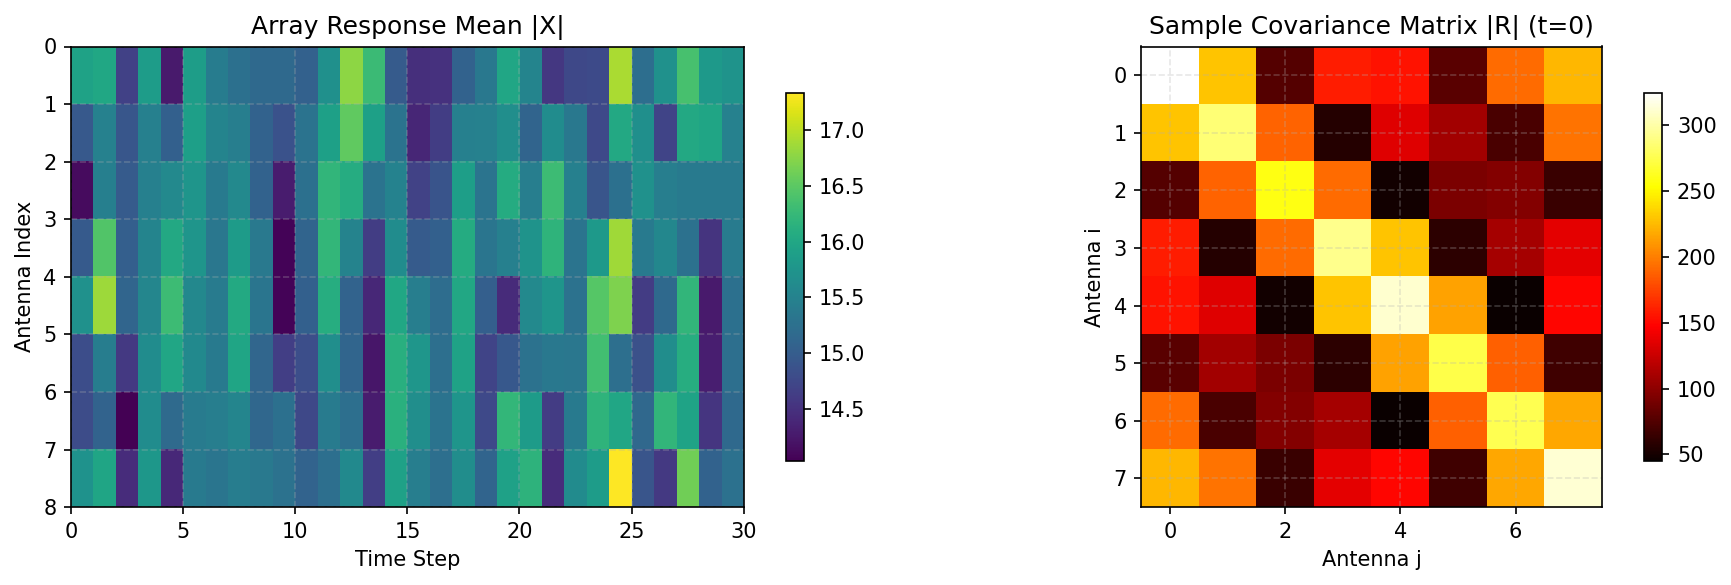

In [7]:
# 3d) Array snapshot heatmap
X0 = dataset.time_series[0]  # [L, N, T]
if isinstance(X0, torch.Tensor):
    X0_np = X0.numpy()
else:
    X0_np = np.asarray(X0)

# Mean magnitude along snapshot dimension -> [L, N]
snapshot_mag = np.mean(np.abs(X0_np), axis=-1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Left: magnitude heatmap
im1 = ax1.imshow(snapshot_mag.T, aspect="auto", cmap="viridis",
                  extent=[0, snapshot_mag.shape[0], config.system_model.N, 0])
ax1.set_xlabel("Time Step")
ax1.set_ylabel("Antenna Index")
ax1.set_title("Array Response Mean |X|")
plt.colorbar(im1, ax=ax1, shrink=0.8)

# Right: sample covariance matrix (first time step)
x_step0 = X0_np[0]  # [N, T]
cov_matrix = np.abs(x_step0 @ x_step0.conj().T) / x_step0.shape[1]
im2 = ax2.imshow(cov_matrix, cmap="hot", interpolation="nearest")
ax2.set_xlabel("Antenna j")
ax2.set_ylabel("Antenna i")
ax2.set_title("Sample Covariance Matrix |R| (t=0)")
plt.colorbar(im2, ax=ax2, shrink=0.8)

fig.tight_layout()
fig.savefig(FIG_DIR / "dataset_array_snapshot_heatmap.png", dpi=180)
plt.show()

## 4) 统计检查

量化关键指标：角度均值/方差/标准差、信号源分布、边界命中率、相邻步角度变化量。

,Metric,Value
0,Total Angles,11520
1,Mean Angle [deg],-0.278
2,Std Angle [deg],18.489
3,Var Angle [deg^2],341.856
4,Boundary Hit Rate,0.0000
5,DOA Range [deg],"[-60, 60]"
6,Mean Step Delta [deg],3.669
7,Max Step Delta [deg],19.325


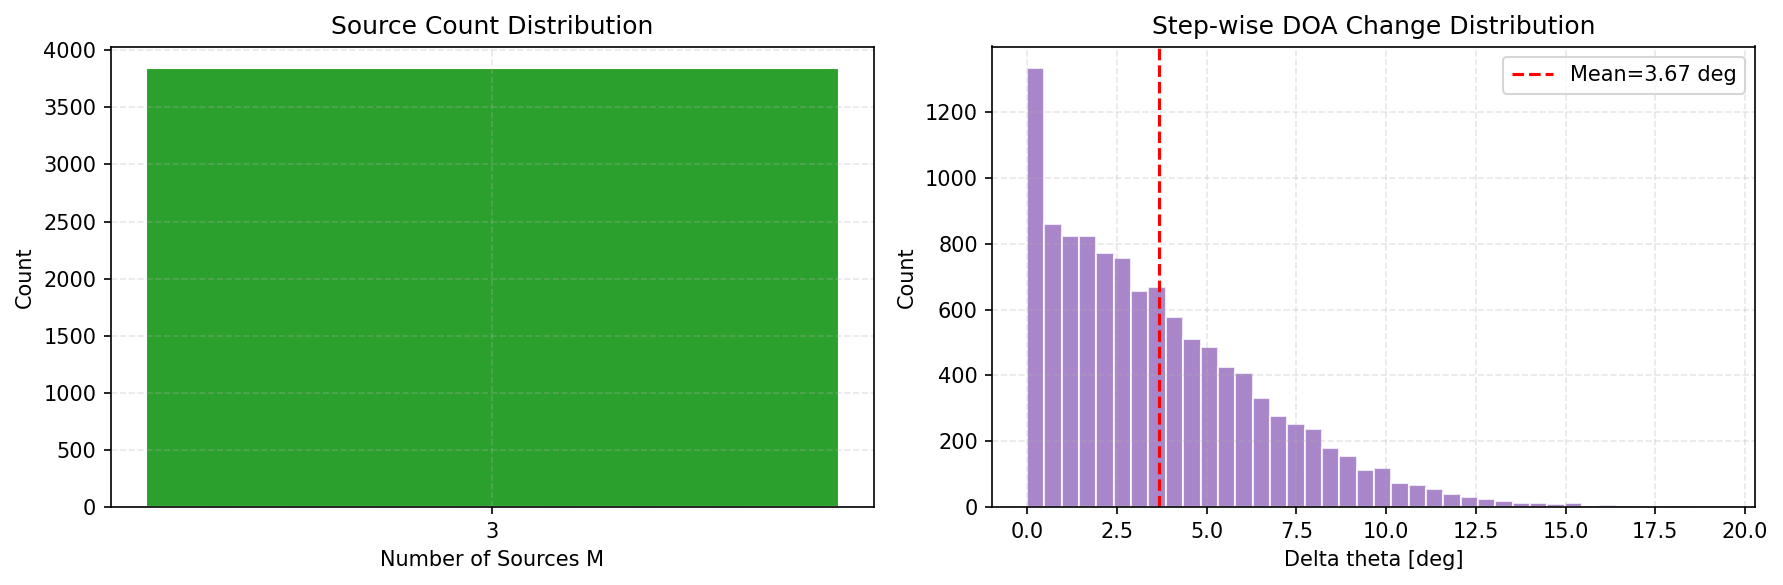

Source count distribution:
source_count
3    3840


In [8]:
# 4) Statistical summary
angles_deg = np.asarray(all_angles_deg, dtype=np.float32)
all_sources = []
for i in range(len(dataset.labels)):
    for t in range(len(dataset.labels[i])):
        all_sources.append(int(dataset.sources_num[i][t]))
src_counts = pd.Series(all_sources, name="source_count")

# Boundary hit detection
doa_bound = config.system_model.doa_range
eps = 0.5  # Within 0.5 deg of boundary counts as a hit
boundary_hits = np.logical_or(
    np.abs(angles_deg - (-doa_bound)) <= eps,
    np.abs(angles_deg - doa_bound) <= eps,
)
boundary_hit_rate = float(boundary_hits.mean()) if len(boundary_hits) else float("nan")

# Step-wise angle change (angular velocity proxy)
step_deltas = []
for i in range(len(dataset.labels)):
    for t in range(1, len(dataset.labels[i])):
        m_prev = int(dataset.sources_num[i][t - 1])
        m_cur = int(dataset.sources_num[i][t])
        m = min(m_prev, m_cur)
        for s in range(m):
            prev_deg = np.rad2deg(float(dataset.labels[i][t - 1][s]))
            cur_deg = np.rad2deg(float(dataset.labels[i][t][s]))
            step_deltas.append(abs(cur_deg - prev_deg))

summary = pd.DataFrame({
    "Metric": [
        "Total Angles", "Mean Angle [deg]", "Std Angle [deg]", "Var Angle [deg^2]",
        "Boundary Hit Rate", "DOA Range [deg]",
        "Mean Step Delta [deg]", "Max Step Delta [deg]",
    ],
    "Value": [
        len(angles_deg),
        f"{np.mean(angles_deg):.3f}" if len(angles_deg) else "N/A",
        f"{np.std(angles_deg):.3f}" if len(angles_deg) else "N/A",
        f"{np.var(angles_deg):.3f}" if len(angles_deg) else "N/A",
        f"{boundary_hit_rate:.4f}",
        f"[-{doa_bound}, {doa_bound}]",
        f"{np.mean(step_deltas):.3f}" if step_deltas else "N/A",
        f"{np.max(step_deltas):.3f}" if step_deltas else "N/A",
    ],
})
display(summary)

# Source count distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

src_dist = src_counts.value_counts().sort_index()
ax1.bar(src_dist.index.astype(str), src_dist.values, color="#2ca02c", edgecolor="white")
ax1.set_title("Source Count Distribution")
ax1.set_xlabel("Number of Sources M")
ax1.set_ylabel("Count")

# Step-wise angle change distribution
if step_deltas:
    ax2.hist(step_deltas, bins=40, color="#9467bd", edgecolor="white", alpha=0.8)
    ax2.axvline(np.mean(step_deltas), color="r", ls="--", lw=1.5,
                label=f"Mean={np.mean(step_deltas):.2f} deg")
    ax2.set_title("Step-wise DOA Change Distribution")
    ax2.set_xlabel("Delta theta [deg]")
    ax2.set_ylabel("Count")
    ax2.legend()

fig.tight_layout()
fig.savefig(FIG_DIR / "dataset_statistics.png", dpi=180)
plt.show()

print("Source count distribution:")
print(src_dist.to_string())

- Total Angles = 11520； 128条轨迹 × 30步 × 3信源 = 11520 ✓，数量对得上
- Mean Angle = -0.278°； 几乎为 0，说明角度分布无系统性偏差 ✓
- Std = 18.489°，Var = 341.856°²

DOA 范围是 ±60°，理论均匀分布的 std = 60/√3 ≈ 34.6°
实际 18.5° 远小于 34.6°，说明角度集中在中间区域，边缘较少
符合随机游走的特性：起点随机，但游走未充分扩散到边界

- Boundary Hit Rate = 0.0000

没有任何角度触碰到 ±60° 边界
结合上面 std 只有 18.5°，说明 random_walk_std_dev 较小，轨迹运动幅度有限，完全没有碰壁压力 ✓
- Mean Step Delta = 3.669°，Max = 19.325°

每步平均移动 3.67°，最大单步 19.3°
对应卡尔曼滤波的过程噪声 Q 应该在同一量级（~3-5°/步）才能有效跟踪
可以查一下 config.kalman_filter.process_noise_std_dev 是否匹配
总体结论：数据健康，无异常。 轨迹运动温和，不碰边界，分布中心对称。

### 统计检查解读

- **方差过低**：数据过于静态，轨迹运动不充分
- **方差过高**：噪声过大或轨迹不稳定
- **边界命中率高**：轨迹裁剪压力大，可能需要增大 `doa_range` 或减小运动幅度
- **步间变化量**：反映信号源运动速度，应与卡尔曼滤波的过程噪声 Q 匹配

## 5) 训练/验证/测试分割验证

验证分割大小、比例和索引无重叠，防止数据泄漏。

In [9]:
from torch.utils.data import random_split

test_ratio, val_ratio, train_ratio = config.dataset.test_validation_train_split
ratio_total = test_ratio + val_ratio + train_ratio
test_ratio, val_ratio, train_ratio = [r / ratio_total for r in (test_ratio, val_ratio, train_ratio)]

n_total = len(dataset)
train_len = max(1, int(n_total * train_ratio)) if n_total >= 3 else max(1, n_total - 2)
val_len = max(1, int(n_total * val_ratio)) if n_total >= 3 else 1
test_len = n_total - train_len - val_len
if test_len <= 0:
    test_len = 1
    if train_len > val_len:
        train_len -= 1
    else:
        val_len -= 1

train_ds, val_ds, test_ds = random_split(
    dataset,
    [train_len, val_len, test_len],
    generator=torch.Generator().manual_seed(42),
)

train_idx = set(train_ds.indices)
val_idx = set(val_ds.indices)
test_idx = set(test_ds.indices)

# 分割报告
split_report = pd.DataFrame({
    "分割": ["训练集", "验证集", "测试集", "总计"],
    "大小": [len(train_ds), len(val_ds), len(test_ds), n_total],
    "比例": [
        f"{len(train_ds)/n_total:.1%}",
        f"{len(val_ds)/n_total:.1%}",
        f"{len(test_ds)/n_total:.1%}",
        "100%",
    ],
    "目标比例": [
        f"{train_ratio:.1%}",
        f"{val_ratio:.1%}",
        f"{test_ratio:.1%}",
        "100%",
    ],
})
display(split_report)

# 泄漏检查
overlap_tv = len(train_idx & val_idx)
overlap_tt = len(train_idx & test_idx)
overlap_vt = len(val_idx & test_idx)
covered = len(train_idx | val_idx | test_idx)

print("=== 数据泄漏检查 ===")
print(f"  train ∩ val  = {overlap_tv}  {'✓' if overlap_tv == 0 else '✗ 存在泄漏!'}")
print(f"  train ∩ test = {overlap_tt}  {'✓' if overlap_tt == 0 else '✗ 存在泄漏!'}")
print(f"  val   ∩ test = {overlap_vt}  {'✓' if overlap_vt == 0 else '✗ 存在泄漏!'}")
print(f"  索引覆盖     = {covered} / {n_total}  {'✓' if covered == n_total else '✗ 索引不完整!'}")

,分割,大小,比例,目标比例
0,训练集,76,59.4%,60.0%
1,验证集,25,19.5%,20.0%
2,测试集,27,21.1%,20.0%
3,总计,128,100%,100%


=== 数据泄漏检查 ===
  train ∩ val  = 0  ✓
  train ∩ test = 0  ✓
  val   ∩ test = 0  ✓
  索引覆盖     = 128 / 128  ✓


In [10]:
# STEP 10: Summarize exported figures and the final dataset/split snapshot.
## 6) 导出摘要

exported = sorted([p.name for p in FIG_DIR.glob("*.png")])
print(f"导出 {len(exported)} 张图表到 {FIG_DIR}：")
for name in exported:
    print(f"  ├── {name}")

print(f"\n=== 分析完成 ===")
print(f"  数据集: {len(dataset)} 条轨迹 × {trajectory_length} 步")
print(f"  系统:   N={config.system_model.N}, M={config.system_model.M}, "
      f"T={config.system_model.T}, SNR={config.system_model.snr}dB")
print(f"  轨迹:   {config.trajectory.trajectory_type}")
print(f"  分割:   {len(train_ds)}/{len(val_ds)}/{len(test_ds)} "
      f"(train/val/test), 无泄漏 ✓")

print("\n后续步骤：")
print("  1. 增大 samples_size 验证统计稳健性")
print("  2. 切换不同 trajectory_type 对比运动模型")
print("  3. 运行 02_model_training.ipynb 进行模型训练")

导出 5 张图表到 /Users/lilei/myRepo/SubspaceNet_Update/figures/nb1：
  ├── dataset_array_snapshot_heatmap.png
  ├── dataset_distribution_violins.png
  ├── dataset_doa_mean_ci.png
  ├── dataset_doa_trajectory.png
  ├── dataset_statistics.png

=== 分析完成 ===
  数据集: 128 条轨迹 × 30 步
  系统:   N=8, M=3, T=200, SNR=10.0dB
  轨迹:   TrajectoryType.RANDOM_WALK
  分割:   76/25/27 (train/val/test), 无泄漏 ✓

后续步骤：
  1. 增大 samples_size 验证统计稳健性
  2. 切换不同 trajectory_type 对比运动模型
  3. 运行 02_model_training.ipynb 进行模型训练
